# Definitions

## Manual Definition

In [1]:
from types import SimpleNamespace
overwrite = SimpleNamespace()

# overwrite.model_space = "VAE"
overwrite.model_space = "PX"

overwrite.scale_factor = 1 # PRoPE / LVSM pre-training
# overwrite.scale_factor = 2 # LVSM fine-tuning

overwrite.patch_size = 8 # LVSM / PRoPE
overwrite.patch_size = 1 # option b for VAE
overwrite.patch_size = 32 # option b for PX

# overwrite.supervise_views = 4 # → will result in 4 in, 1 out
overwrite.supervise_views = 0 # → will result in 1 in, 1 out

# overwrite.dim_feedforward = 3072 # LVSM / PRoPE - large
overwrite.dim_feedforward = 1024 # PRoPE - small

overwrite.num_layers = 6 # PRoPE - small
# overwrite.num_layers = 12 # PRoPE - large

# LVSM:
# For scene-level experiments We use 2 input views and 6 target views for each training example.

## Generating all Combinations

In [64]:
from itertools import product
from types import SimpleNamespace

def generate_overwrite_configs():
    model_spaces = ["VAE", "PX"]
    scale_factors = [1, 2]
    # scale_factors = [1]
    supervise_views = [0, 3, 7, 15] # dataloader will load n = (supervise_views + 2 images) and use n-1 for training => supervise_views + 1 tanslates to context images
    dim_feedforwards = [1024, 3072]
    num_layers = [6, 12]

    all_configs = []

    for model_space in model_spaces:

        # patch_size depends on model_space
        if model_space == "VAE":
            # patch_sizes = [1, 8]
            patch_sizes = [2]
        else:  # PX
            # patch_sizes = [8, 64]
            patch_sizes = [8]

        # make cartesian product with allowed settings
        for (scale_factor,
             patch_size,
             sv,
             dff,
             nl) in product(scale_factors,
                            patch_sizes,
                            supervise_views,
                            dim_feedforwards,
                            num_layers):

            ow = SimpleNamespace()
            ow.model_space = model_space
            ow.scale_factor = scale_factor
            ow.patch_size = patch_size
            ow.supervise_views = sv
            ow.dim_feedforward = dff
            ow.num_layers = nl

            all_configs.append(ow)

    return all_configs

# Example usage:
configs = generate_overwrite_configs()
print("Total configs:", len(configs))
print(vars(configs[11]))
# for i in range(len(configs)):
#     print(f"config {i}")
#     print(vars(configs[i]))
# configs = configs[11:12]

Total configs: 64
{'model_space': 'VAE', 'scale_factor': 1, 'patch_size': 2, 'supervise_views': 7, 'dim_feedforward': 3072, 'num_layers': 12}


# Functions

In [61]:
import sys
import os
project_root = os.path.abspath("..")
sys.path.append(project_root)

import torch
import yaml
import re
import glob
from pathlib import Path

from src.models.lvsm_decoder_only import LVSMDecoderOnlyModel
from src.configs.lvsm_decoder_only_config import (
    LVSMDecoderOnlyModelConfig,
    RayEncodingType,
    PosEncType,
)
from src.prope.utils.transformer import (
    TransformerEncoderConfig,
    TransformerEncoderLayerConfig,
)


from src.data.dataset import TrainDataset
from src.data.latent_dataset import TrainLatentDataset
from main import LVSMLauncher, LVSMLauncherConfig

device = "cuda" if torch.cuda.is_available() else "cpu"


def get_config(overwrite):           
    
    dir = "../assets/vae_config.yaml" if overwrite.model_space == "VAE" else "../assets/px_config.yaml"
    raw = Path(dir).read_text()    
    clean = re.sub(r"!!python/[^ \n]+", "", raw)   # strip python tags

    config_dict = yaml.safe_load(clean)    
    cfg = LVSMLauncherConfig()

    for k, v in config_dict.items():
        if k != "model_config":   # we'll rebuild this separately
            setattr(cfg, k, v)
    
    m = config_dict["model_config"]

    # Enums were dumped as single-item lists
    ray_encoding = RayEncodingType(m["ray_encoding"][0])
    pos_enc      = PosEncType(m["pos_enc"][0])
    
    layer_cfg = m["encoder"]["layer"]

    encoder_layer = TransformerEncoderLayerConfig(
        d_model=layer_cfg["d_model"],
        nhead=layer_cfg["nhead"],
        dim_feedforward=overwrite.dim_feedforward,
        dropout=layer_cfg["dropout"],
        activation=torch.nn.functional.relu,  # original activation
        batch_first=layer_cfg["batch_first"],
        bias=layer_cfg["bias"],
        layer_norm_eps=layer_cfg["layer_norm_eps"],
        modulation_activation=layer_cfg["modulation_activation"],
        norm_first=layer_cfg["norm_first"],
        norm_type=layer_cfg["norm_type"],
        elementwise_affine=layer_cfg["elementwise_affine"],
        qk_norm=layer_cfg["qk_norm"],
    )
    
    encoder = TransformerEncoderConfig(
        layer=encoder_layer,
        num_layers=overwrite.num_layers,
        input_norm=m["encoder"]["input_norm"],
        output_norm=m["encoder"]["output_norm"],
        checkpointing=m["encoder"]["checkpointing"],
    )

    # Full model config
    model_cfg = LVSMDecoderOnlyModelConfig(
        ref_views=m["ref_views"],
        tar_views=m["tar_views"],
        encoder=encoder,
        img_shape=tuple([m["img_shape"][0]*overwrite.scale_factor, m["img_shape"][1]*overwrite.scale_factor,m["img_shape"][2]]),
        cam_shape=tuple([m["cam_shape"][0]*overwrite.scale_factor, m["cam_shape"][1]*overwrite.scale_factor,m["cam_shape"][2]]),        
        patch_size=overwrite.patch_size,        
        ray_encoding=ray_encoding,
        pos_enc=pos_enc,
    )
    
    cfg.model_config = model_cfg    
    return cfg

def load_checkpoint(model, dir):
    def get_latest_checkpoint(ckpt_dir):
        ckpts = sorted(glob.glob(os.path.join(ckpt_dir, "*.pt")))
        return ckpts[-1] if ckpts else None

    ckpt_path = get_latest_checkpoint(f"{dir}/ckpts")
    print("Loading checkpoint:", ckpt_path)

    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model"].items()}
    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)
    return model



def load_single_batch(cfg: LVSMLauncherConfig, overwrite):
    """
    Loads ONE batch from the appropriate dataset based on cfg.model_space.
    Returns ref_imgs, tar_imgs, ref_cams, tar_cams, ref_paths, tar_paths.
    """

    launcher = LVSMLauncher(cfg)
    
    if cfg.model_space == "PX":
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k/train/*"))
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k/overfit/*"))
        scenes = sorted(glob.glob("../data/data_processed/realestate10k/overfit-2/*"))
        dataset = TrainDataset(
            scenes,
            patch_size=cfg.dataset_patch_size,
            zoom_factor=cfg.train_zoom_factor,
            random_zoom=cfg.random_zoom,            
            supervise_views=overwrite.supervise_views, # will return 2 + supervise_views images
            upscale_factor=overwrite.scale_factor
        )
    else:
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k_latent/train/*"))
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k_latent/overfit/*"))
        scenes = sorted(glob.glob("../data/data_processed/realestate10k_latent/overfit-2/*"))        
        dataset = TrainLatentDataset(
            scenes,                
            supervise_views=overwrite.supervise_views,       
            upscale_factor=overwrite.scale_factor
        )    

    data = dataset[0] # just one scene
    data["image"] = data["image"].unsqueeze(0)
    data["K"] = data["K"].unsqueeze(0)
    data["camtoworld"] = data["camtoworld"].unsqueeze(0)
    data["image_path"] = [data["image_path"]]  # wrap in list    

    input_views = data["K"].shape[1] - cfg.dataset_supervise_views # input views = available images - 1 (output)
    
    processed = launcher.preprocess(data, input_views=input_views)

    ref_imgs = processed["ref_imgs"]
    tar_imgs = processed["tar_imgs"]
    ref_cams = processed["ref_cams"]
    tar_cams = processed["tar_cams"]
    ref_paths = processed["ref_paths"]
    tar_paths = processed["tar_paths"]

    return ref_imgs, tar_imgs, ref_cams, tar_cams, ref_paths, tar_paths



import time
import torch
import torch.nn.functional as F

def tensor_bytes(x: torch.Tensor) -> int:
    return x.numel() * x.element_size()

def encode_tensors(img: torch.Tensor, vae, device, sequentially = True) -> torch.Tensor:
    """
    Accepts:
        [H, W, 3]
        [V, H, W, 3]
        [B, V, H, W, 3]

    Returns:
        Same leading dims, but encoded latents:
        [.., H_down, W_down, C_latent]
    """

    # img = img.to(device).float()

    # Original leading dims: (), (V), or (B, V)
    orig_shape = img.shape[:-3]
    H, W, C = img.shape[-3:]
    assert C == 3, f"Expected RGB input but got {C} channels"

    # Flatten leading dims
    img = img.reshape(-1, H, W, C)        # [N, H, W, 3]

    # Convert to NCHW
    img = img.permute(0, 3, 1, 2)         # [N, 3, H, W]

    # Scale to [-1, 1] just like training
    img = img * 2 - 1

    with torch.no_grad():
        if sequentially:
            latents_cpu = []
            for i in range(img.shape[0]):
                posterior = vae.encode(img[i].unsqueeze(0).to(device).float())
                latent = posterior.latent_dist.mean.squeeze(0).detach().cpu()  # offload
                latents_cpu.append(latent)

            latents = torch.stack(latents_cpu, dim=0).to(img.device)  # back to GPU
        else:
            posterior = vae.encode(img)
            latents = posterior.latent_dist.mean   # [N, C_lat, H_down, W_down]

    # Back to NHWC
    latents = latents.permute(0, 2, 3, 1)   # [N, H_down, W_down, C_lat]


    # Restore original leading dims
    latents = latents.reshape(*orig_shape,
                              latents.shape[1],
                              latents.shape[2],
                              latents.shape[3])

    return latents


def scale_spatial(img: torch.Tensor, factor: int) -> torch.Tensor:
    """
    Inputs:
        img: [B, V, H, W, C]
    Returns:
        [B, V, H*factor, W*factor, C]

    Uses bilinear interpolation. Assumes img is on any device.
    """

    B, V, H, W, C = img.shape
    img_nchw = img.permute(0, 1, 4, 2, 3).reshape(B*V, C, H, W)

    img_up = F.interpolate(
        img_nchw,
        size=(H * factor, W * factor),
        mode="bilinear",
        align_corners=False
    )
    img_up = img_up.reshape(B, V, C, H*factor, W*factor).permute(0, 1, 3, 4, 2)

    return img_up


def run_inference_with_metrics(model, launcher, ref_imgs, ref_cams, tar_cams, cfg, device="cuda", scale_factor=1):    

    model_params = sum(p.numel() for p in model.parameters())
    
    input_tensors = [ref_imgs]
    input_bytes = sum(tensor_bytes(t) for t in input_tensors if isinstance(t, torch.Tensor))    
    
    forward_memory_mb = 0.0
    encode_memory_mb = 0.0
    decode_memory_mb = 0.0
    peak_memory_mb = 0.0
    encode_peak = 0.0
    encode_time_ms = 0.0

    t_enc1 = time.time()
    

    if cfg.model_space == "VAE":
        decoded = launcher.decode_tensors(ref_imgs).cpu()
        # print(f"ref_imgs.shape {ref_imgs.shape}")             
        if scale_factor > 1:
            decoded = scale_spatial(decoded, scale_factor)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats(device)
        
        t_enc1 = time.time()
        encode_tensors(decoded, launcher.vae32, device, sequentially=True)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        encode_time_ms = (time.time() - t_enc1)* 1000
        if torch.cuda.is_available():
            encode_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)
        encode_peak = torch.cuda.max_memory_allocated(device)

    # ------------------------------------------
    # Forward pass timing + memory
    # ------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
    t_fwd0 = time.time()

    # print(f"ref_imgs.shape {ref_imgs.shape}")
    # print(f"ref_cams.shape {len(ref_cams)}")
    # print(f"tar_cams.shape {len(tar_cams)}")
    with torch.inference_mode():
        out = model(ref_imgs.to(device), ref_cams, tar_cams)

    torch.cuda.synchronize()
    t_fwd1 = time.time()

    forward_time_ms = (t_fwd1 - t_fwd0) * 1000

    # Memory AFTER forward pass
    if torch.cuda.is_available():
        forward_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)

    # Keep the forward peak BEFORE decoding wipes it out
    forward_peak = torch.cuda.max_memory_allocated(device)
    
    if cfg.model_space == "VAE":

        # Reset for decode-only measurement
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
        t_dec0 = time.time()

        decoded = launcher.decode_tensors(out[0])

        torch.cuda.synchronize()
        t_dec1 = time.time()
        decode_time_ms = (t_dec1 - t_dec0) * 1000

        decode_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)

    else:
        decoded = torch.sigmoid(out)
        decode_time_ms = 0.0
        decode_memory_mb = 0.0
    
    peak_memory_mb = max(encode_peak, forward_peak, torch.cuda.max_memory_allocated(device)) / (1024**2)    
    total_time_ms = forward_time_ms + decode_time_ms + encode_time_ms


    return {
        "model_space": cfg.model_space,
        "patch_size" : cfg.model_config.patch_size,
        "layers": cfg.model_config.encoder.num_layers,
        "dim_feedforward": cfg.model_config.encoder.layer.dim_feedforward,
        "scale_factor" : scale_factor,        
        "ref_views" : ref_imgs.shape[1],
        "model_params": model_params,
        "input_bytes": input_bytes,
        "input_MB": input_bytes / (1024**2),
        "encode_time_ms": encode_time_ms,
        "forward_time_ms": forward_time_ms,
        "decode_time_ms": decode_time_ms,
        "total_time_ms": total_time_ms,
        "encode_memory_mb": encode_memory_mb,
        "forward_memory_mb": forward_memory_mb,
        "decode_memory_mb": decode_memory_mb,
        "peak_memory_mb": peak_memory_mb,
        # "output_shape": tuple(out.shape),
        # "decoded_shape": tuple(decoded.shape),
    }


In [5]:

def evaluate(config):
    cfg = get_config(config)
    model = LVSMDecoderOnlyModel(cfg.model_config).to(device)
    model.eval()

    ref_imgs, tar_imgs, ref_cams, tar_cams, ref_paths, tar_paths = load_single_batch(cfg, config)

    launcher = LVSMLauncher(cfg)
    return run_inference_with_metrics(
        model=model,
        launcher=launcher,
        ref_imgs=ref_imgs,
        ref_cams=ref_cams,
        tar_cams=tar_cams,
        cfg=cfg,
        scale_factor=config.scale_factor
    )

In [65]:
results_file = "../results/performance_comparison/260129_results_4.json"

In [56]:
configs

[namespace(model_space='VAE',
           scale_factor=1,
           patch_size=2,
           supervise_views=7,
           dim_feedforward=3072,
           num_layers=12)]

In [62]:
results = []

import json

n_iterations = 10
# n_iterations = 1
total = len(configs) * n_iterations
count = 0

for config in configs:
    for n in range(n_iterations):
        metrics = evaluate(config)        
        results.append(metrics)      
        count += 1
        print(f"[{count}/{total}] {count/total*100:.1f}% done")  

# metrics = evaluate(configs[28])
# print(configs[28])
# print(json.dumps(metrics, indent=4))

with open(results_file, "w") as f:
    json.dump(results,f,indent=4)


Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
training on latent dataset
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml


/home/felix/LVSM-VAE/src/data/latent_dataset.py:243: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image = torch.load(abs_image_path)


[1/10] 10.0% done
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
training on latent dataset
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
[2/10] 20.0% done
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
training on latent dataset
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
[3/10] 30.0% done
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
training on latent dataset
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
[4/10] 40.0% done
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
training on latent dataset
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
[5/10] 50.0% done
Wrote config to results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/config.yaml
training on latent dataset
Wrote config to results/nvs/VAE/release-1gpus-

# Plots

In [32]:
# time-memory scatter plot

# import matplotlib.pyplot as plt

# total_time = [d["total_time_ms"] for d in collection]
# peak_mem = [d["peak_memory_mb"] for d in collection]

# plt.figure(figsize=(6,4))
# plt.scatter(total_time, peak_mem)
# plt.xlabel("total_time_ms")
# plt.ylabel("peak_memory_mb")
# plt.title("Scatter Plot of Total Time vs Peak Memory")
# plt.tight_layout()
# plt.show()


In [57]:
# fix scale issue

# import json
# from pathlib import Path

# # Path to your results file

# # Load
# data = json.loads(path.read_text())

# # Safety check
# print(f"Loaded {len(data)} entries")

# # Replace scale_factor for the specified slices
# for idx in list(range(160, 320)) + list(range(480, 640)):
#     if idx < len(data):
#         data[idx]["scale_factor"] = 2

# print("Updated entries in ranges 160–319 and 480–639")

# # Save back to disk (overwrite)
# path.write_text(json.dumps(data, indent=4))
# print("Saved updated results.json")

In [63]:
import json
from pathlib import Path
from collections import defaultdict

# Load results
path = Path(results_file)
data = json.loads(path.read_text())

print("\n=== Loaded entries:", len(data), "===\n")

# Print the distinct values for each field
fields = ["model_space", "patch_size", "scale_factor", "ref_views",
          "layers", "dim_feedforward"]

distinct = {f: set() for f in fields}

for e in data:
    for f in fields:
        distinct[f].add(e.get(f))

print("=== Distinct values in the dataset ===")
for f in distinct:
    print(f"{f}: {sorted(distinct[f])}")



=== Loaded entries: 10 ===

=== Distinct values in the dataset ===
model_space: ['VAE']
patch_size: [2]
scale_factor: [1]
ref_views: [8]
layers: [12]
dim_feedforward: [3072]


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

# path = Path("../results/performance_comparison/260129_results_3.json")
path = Path(results_file)
data = json.loads(path.read_text())

# --- group and average ---
groups = defaultdict(list)
for e in data:
    key = (
        e["model_space"],
        e["patch_size"],
        e["scale_factor"],
        e["ref_views"],
        e["layers"],
        e["dim_feedforward"],
    )
    groups[key].append(e)

mean_results = {}
for key, items in groups.items():
    avg = {}
    for k, v in items[0].items():
        if isinstance(v, (int, float)):
            avg[k] = sum(x.get(k, 0) for x in items) / len(items)
        else:
            avg[k] = v
    mean_results[key] = avg

print("Total unique configs:", len(mean_results))


def get_unique(field, *, filters=None):
    """Return sorted unique values for a field across mean_results keys."""
    filters = filters or {}
    vals = set()
    for (ms, ps, sf, rv, lyr, ff) in mean_results.keys():
        if "model_space" in filters and ms not in filters["model_space"]:
            continue
        if "patch_size" in filters and ps not in filters["patch_size"]:
            continue
        if "scale_factor" in filters and sf not in filters["scale_factor"]:
            continue
        if "ref_views" in filters and rv not in filters["ref_views"]:
            continue
        if "layers" in filters and lyr not in filters["layers"]:
            continue
        if "dim_feedforward" in filters and ff not in filters["dim_feedforward"]:
            continue

        mapping = {
            "model_space": ms,
            "patch_size": ps,
            "scale_factor": sf,
            "ref_views": rv,
            "layers": lyr,
            "dim_feedforward": ff,
        }
        vals.add(mapping[field])
    return sorted(vals)


def available_conditions(vae_patch, px_patch, layers, dff, scale_factors=None, ref_views=None):
    """Discover (sf, rv) pairs that exist for BOTH VAE and PX for the given patches + hyperparams."""
    conds = set()
    for (ms, ps, sf, rv, lyr, ff) in mean_results.keys():
        if lyr != layers or ff != dff:
            continue
        if scale_factors is not None and sf not in scale_factors:
            continue
        if ref_views is not None and rv not in ref_views:
            continue
        # we'll check existence for both spaces below
        conds.add((sf, rv))

    final = []
    for sf, rv in sorted(conds, key=lambda x: (x[1], x[0])):
        k_vae = ("VAE", vae_patch, sf, rv, layers, dff)
        k_px  = ("PX",  px_patch,  sf, rv, layers, dff)
        if k_vae in mean_results and k_px in mean_results:
            final.append((sf, rv))
        else:
            # keep going; plotting should reflect what's truly comparable
            pass

    return final


def collect_subset(vae_patch, px_patch, layers, dff, scale_factors=None, ref_views=None, conditions=None):
    if conditions is None:
        conditions = available_conditions(
            vae_patch, px_patch, layers, dff,
            scale_factors=scale_factors,
            ref_views=ref_views
        )

    labels = [f"sf={sf}, rv={rv}" for sf, rv in conditions]

    subset = []
    for sf, rv in conditions:
        key_vae = ("VAE", vae_patch, sf, rv, layers, dff)
        key_px  = ("PX",  px_patch,  sf, rv, layers, dff)
        subset.append((mean_results.get(key_vae), mean_results.get(key_px)))

    return labels, subset


def safe_get(d, k, default=0.0):
    return float(d.get(k, default)) if d is not None else float(default)


# color scheme: blues for VAE, orange for PX
colors = {
    "vae_encode":  "#bdd7e7",
    "vae_forward": "#6baed6",
    "vae_decode":  "#3182bd",
    "px_total":    "#fdae6b",
}


def plot_subset(labels, subset, title_prefix, layers, ff_dim):
    if not labels:
        print(f"No comparable conditions found for {title_prefix} (layers={layers}, dff={ff_dim}).")
        return

    y = np.arange(len(labels))

    # --- TIME ---
    fig, ax = plt.subplots(figsize=(12, 6))

    vae_enc  = [safe_get(v, "encode_time_ms")  for v, _ in subset]
    vae_fwd  = [safe_get(v, "forward_time_ms") for v, _ in subset]
    vae_dec  = [safe_get(v, "decode_time_ms")  for v, _ in subset]
    px_total = [safe_get(p, "total_time_ms")   for _, p in subset]

    h = 0.35
    ax.barh(y - h/2, vae_enc, h, color=colors["vae_encode"],  label="VAE – encode")
    ax.barh(y - h/2, vae_fwd, h, left=vae_enc, color=colors["vae_forward"], label="VAE – forward")
    ax.barh(
        y - h/2, vae_dec, h,
        left=np.array(vae_enc) + np.array(vae_fwd),
        color=colors["vae_decode"], label="VAE – decode"
    )
    ax.barh(y + h/2, px_total, h, color=colors["px_total"], label="PX – total time")

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Time (ms)")
    ax.set_title(f"layers: {layers} / ff_dim: {ff_dim}\n{title_prefix} – Time")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- MEMORY ---
    fig, ax = plt.subplots(figsize=(12, 6))

    vae_enc_mem = [safe_get(v, "encode_memory_mb")  for v, _ in subset]
    vae_fwd_mem = [safe_get(v, "forward_memory_mb") for v, _ in subset]
    vae_dec_mem = [safe_get(v, "decode_memory_mb")  for v, _ in subset]
    # PX might store either peak_memory_mb or forward_memory_mb etc; use peak as primary
    px_mem      = [safe_get(p, "peak_memory_mb")    for _, p in subset]

    h2 = 0.2
    ax.barh(y - 1.5*h2, vae_enc_mem, h2, color=colors["vae_encode"],  label="VAE – encode memory")
    ax.barh(y - 0.5*h2, vae_fwd_mem, h2, color=colors["vae_forward"], label="VAE – forward memory")
    ax.barh(y + 0.5*h2, vae_dec_mem, h2, color=colors["vae_decode"],  label="VAE – decode memory")
    ax.barh(y + 1.5*h2, px_mem,      h2, color=colors["px_total"],    label="PX – peak memory")

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Memory (MB)")
    ax.set_title(f"layers: {layers} / ff_dim: {ff_dim}\n{title_prefix} – Memory")
    ax.legend()
    plt.tight_layout()
    plt.show()


# -------------------------
# Example: your desired generalization
# -------------------------

# 1) choose one patch size per model_space (hardcode yours here)
vae_patch = 2
px_patch  = 8

# 2) choose one scale factor or leave None to use all
scale_factors = {1}        # <- "only 1 scale factor"
# scale_factors = None        # <- "only 1 scale factor"
ref_views = None           # <- or e.g. {1,2,4,8} if you have exactly 4 supervise views

# 3) choose one (layers, dff) or iterate over whatever exists
layers = 6
dff = 1024

labels, subset = collect_subset(vae_patch, px_patch, layers, dff,
                                scale_factors=scale_factors, ref_views=ref_views)

plot_subset(labels, subset, f"VAE(p{vae_patch}) vs PX(p{px_patch})", layers, dff)

layers = 12
dff = 3072

labels, subset = collect_subset(vae_patch, px_patch, layers, dff,
                                scale_factors=scale_factors, ref_views=ref_views)
plot_subset(labels, subset, f"VAE(p{vae_patch}) vs PX(p{px_patch})", layers, dff)


Total unique configs: 1
No comparable conditions found for VAE(p2) vs PX(p8) (layers=6, dff=1024).
No comparable conditions found for VAE(p2) vs PX(p8) (layers=12, dff=3072).


In [32]:
data

[{'model_space': 'VAE',
  'patch_size': 2,
  'layers': 6,
  'dim_feedforward': 1024,
  'scale_factor': 1,
  'ref_views': 1,
  'model_params': 23739632,
  'input_bytes': 65536,
  'input_MB': 0.0625,
  'encode_time_ms': 10.788917541503906,
  'forward_time_ms': 62.08181381225586,
  'decode_time_ms': 115.73219299316406,
  'total_time_ms': 188.60292434692383,
  'encode_memory_mb': 621.52587890625,
  'forward_memory_mb': 444.951171875,
  'decode_memory_mb': 615.40185546875,
  'peak_memory_mb': 621.52587890625},
 {'model_space': 'VAE',
  'patch_size': 2,
  'layers': 6,
  'dim_feedforward': 1024,
  'scale_factor': 1,
  'ref_views': 1,
  'model_params': 23739632,
  'input_bytes': 65536,
  'input_MB': 0.0625,
  'encode_time_ms': 10.570526123046875,
  'forward_time_ms': 68.82548332214355,
  'decode_time_ms': 115.80514907836914,
  'total_time_ms': 195.20115852355957,
  'encode_memory_mb': 615.40185546875,
  'forward_memory_mb': 444.951171875,
  'decode_memory_mb': 615.40185546875,
  'peak_memory_m

Total unique configs: 96

Configs with layers=6, dim_feedforward=1024:
('VAE', 1, 1, 1, 6, 1024)
('VAE', 1, 1, 4, 6, 1024)
('VAE', 2, 1, 1, 6, 1024)
('VAE', 2, 1, 4, 6, 1024)
('VAE', 8, 1, 1, 6, 1024)
('VAE', 8, 1, 4, 6, 1024)
('VAE', 1, 2, 1, 6, 1024)
('VAE', 1, 2, 4, 6, 1024)
('VAE', 2, 2, 1, 6, 1024)
('VAE', 2, 2, 4, 6, 1024)
('VAE', 8, 2, 1, 6, 1024)
('VAE', 8, 2, 4, 6, 1024)
('PX', 8, 1, 1, 6, 1024)
('PX', 8, 1, 4, 6, 1024)
('PX', 16, 1, 1, 6, 1024)
('PX', 16, 1, 4, 6, 1024)
('PX', 64, 1, 1, 6, 1024)
('PX', 64, 1, 4, 6, 1024)
('PX', 8, 2, 1, 6, 1024)
('PX', 8, 2, 4, 6, 1024)
('PX', 16, 2, 1, 6, 1024)
('PX', 16, 2, 4, 6, 1024)
('PX', 64, 2, 1, 6, 1024)
('PX', 64, 2, 4, 6, 1024)


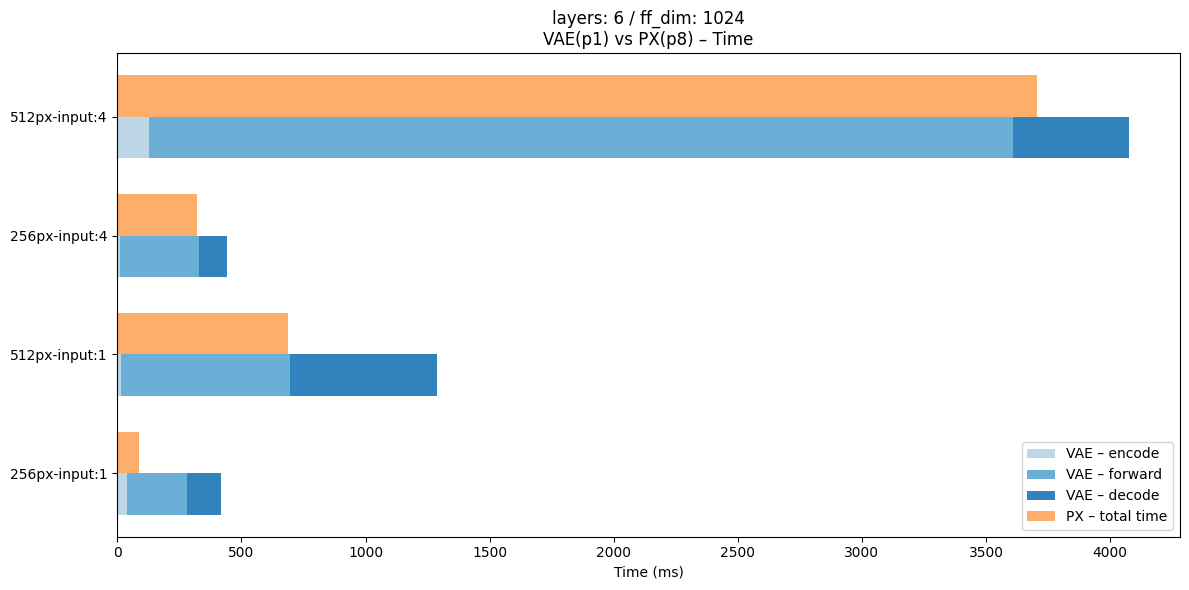

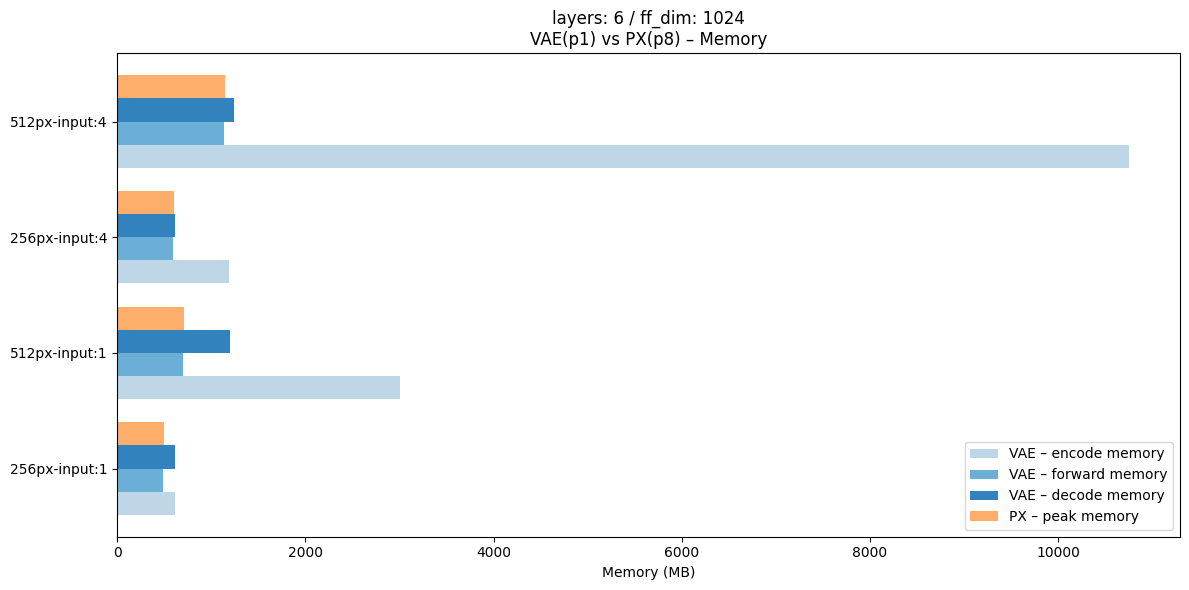

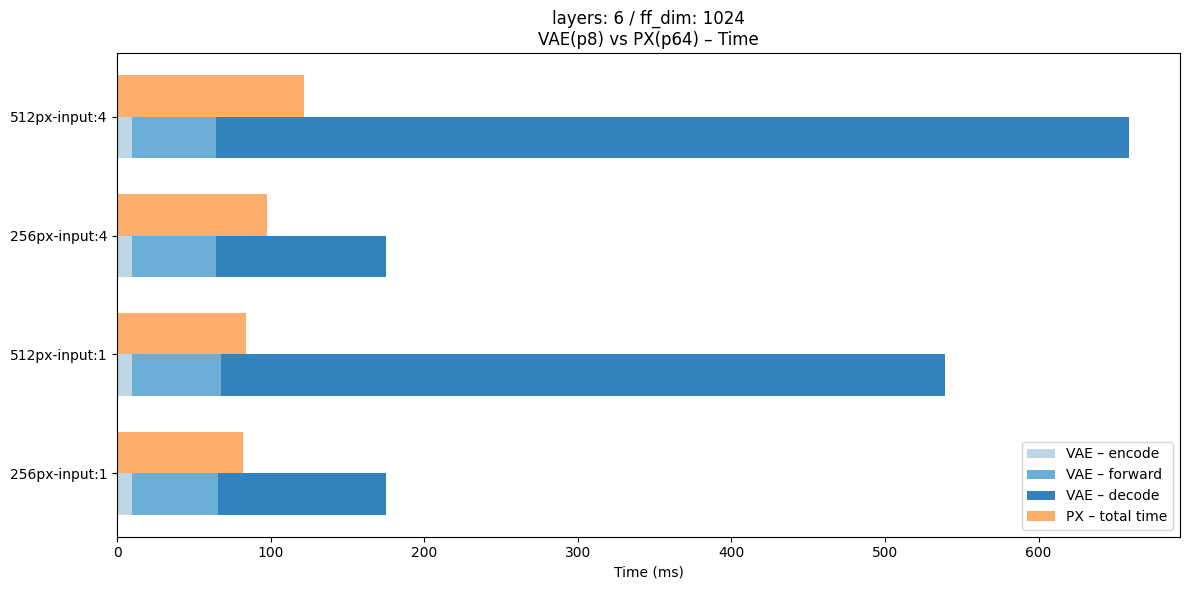

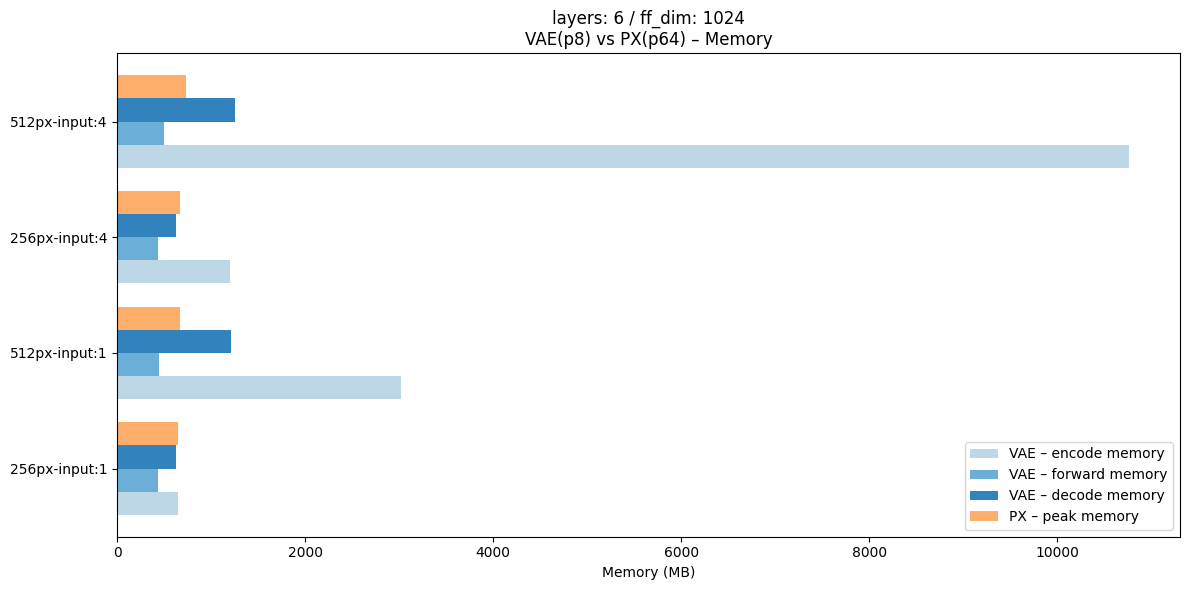

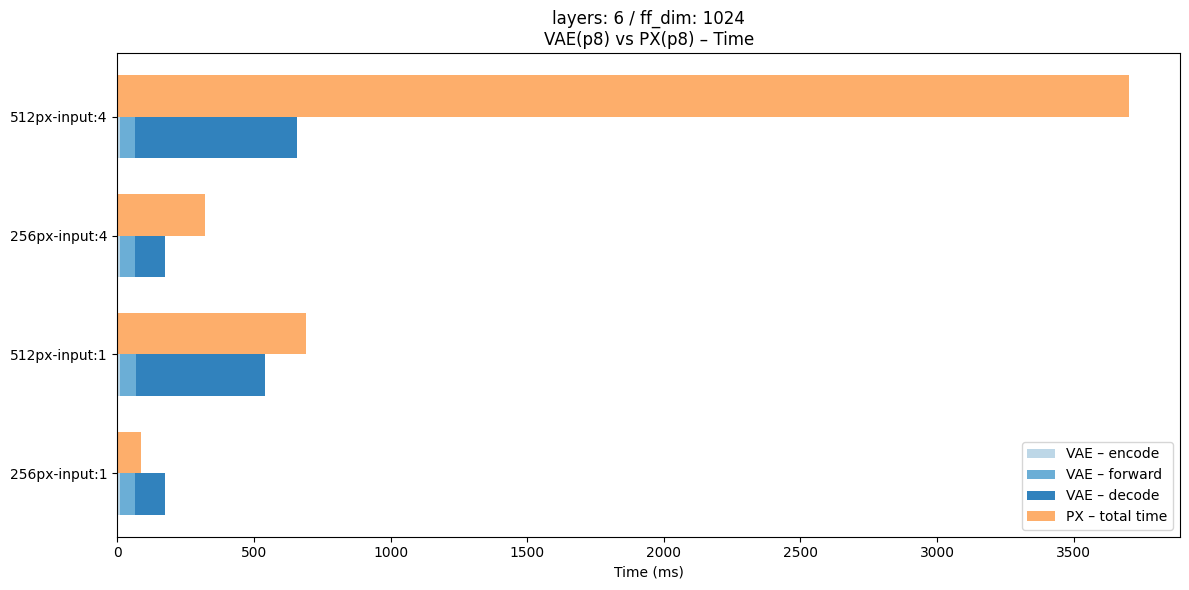

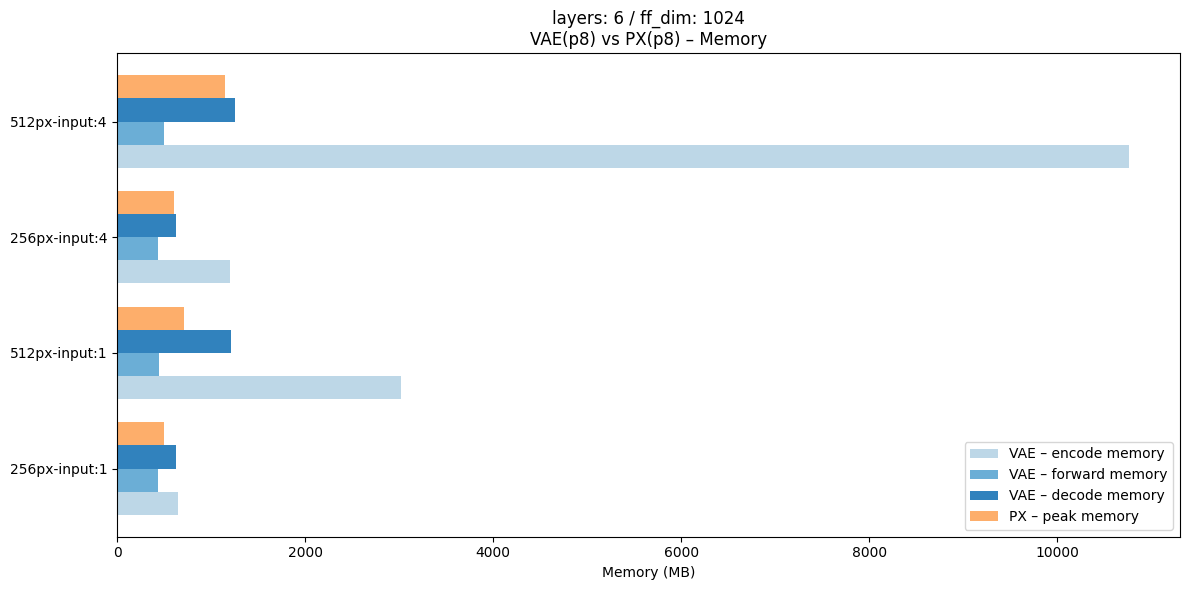

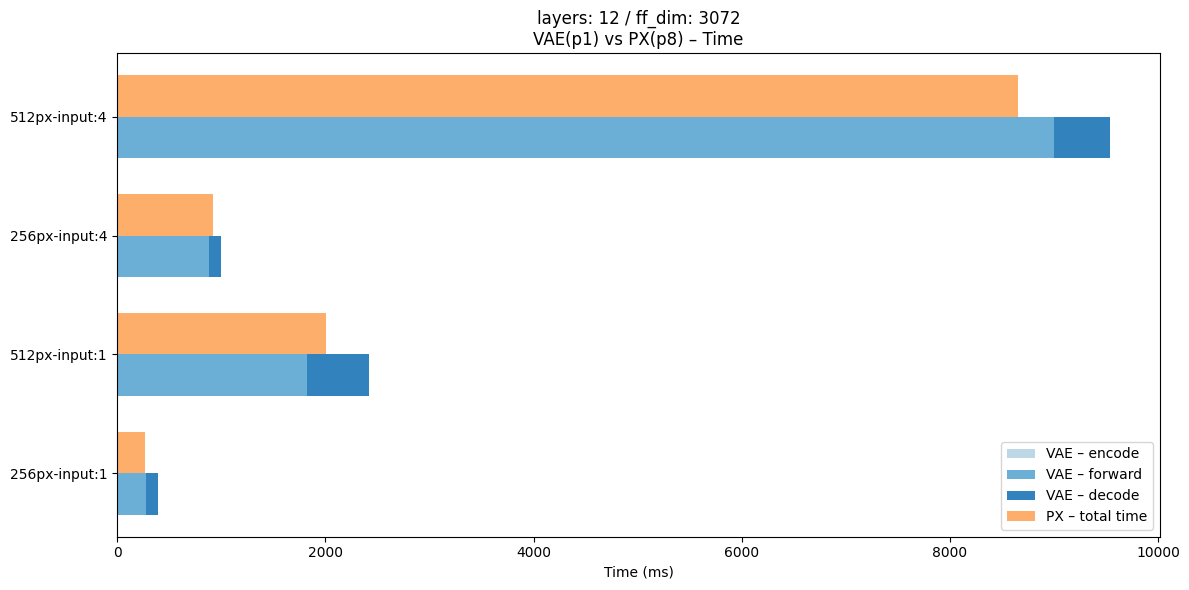

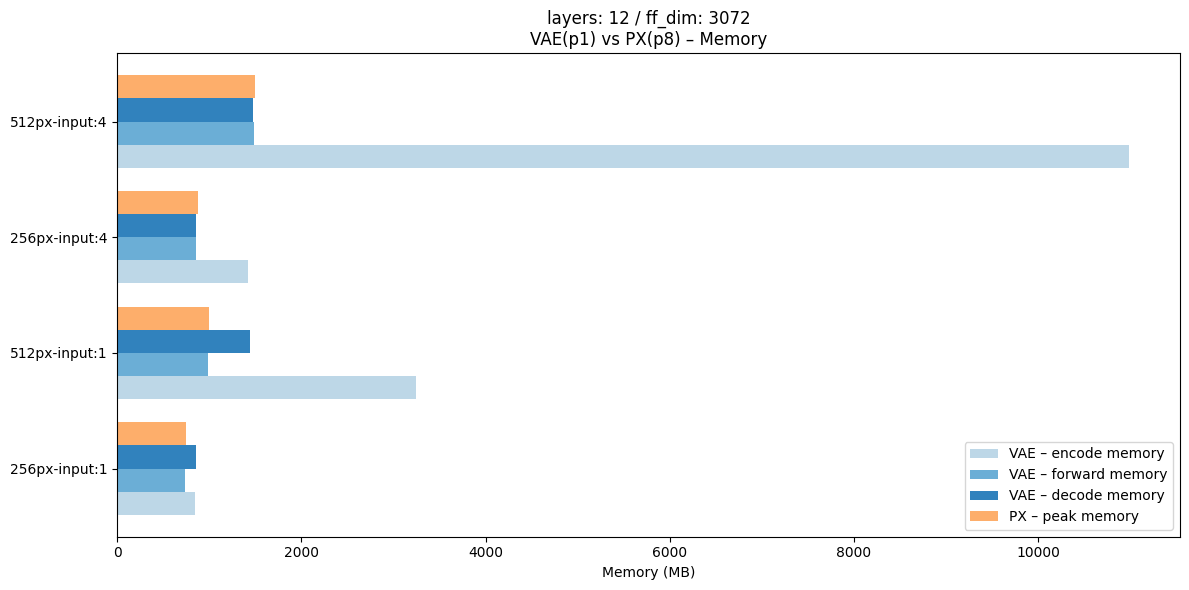

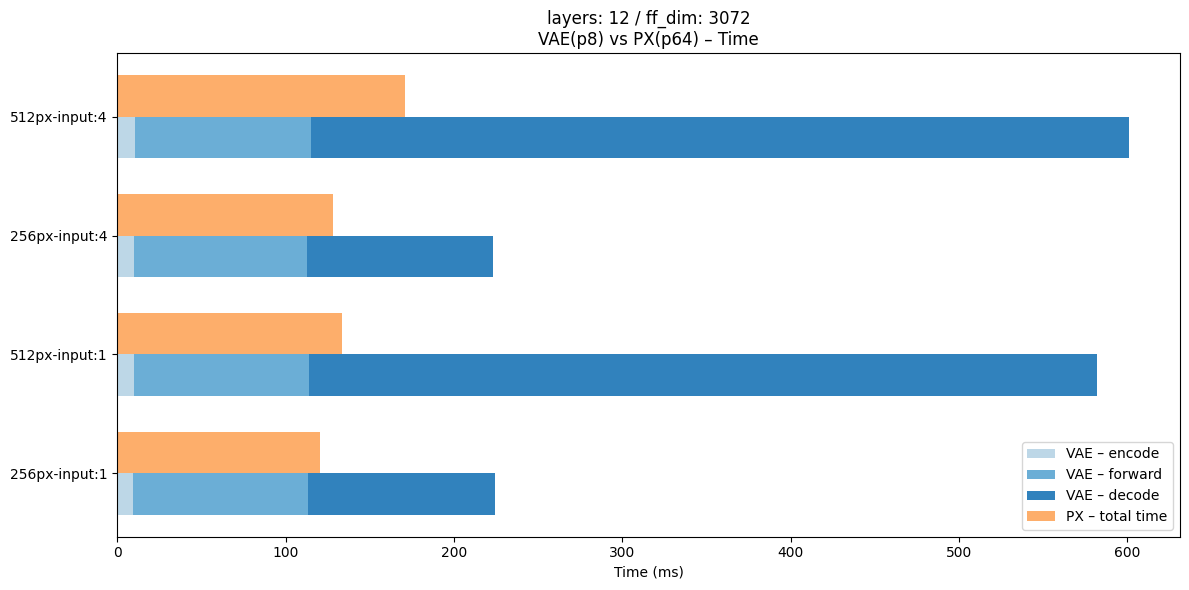

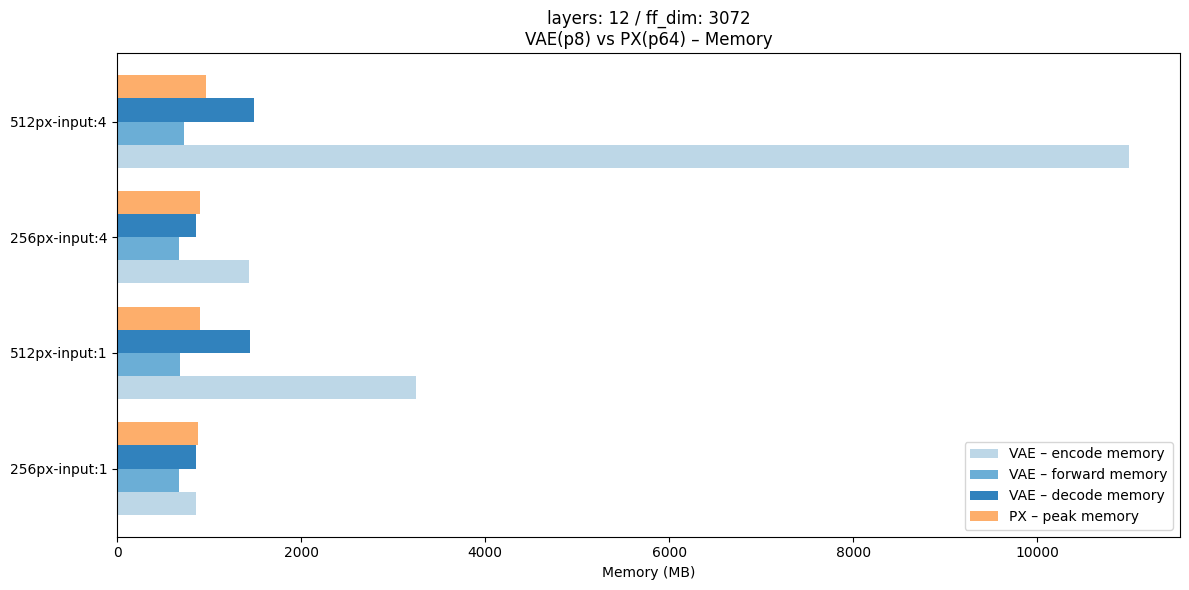

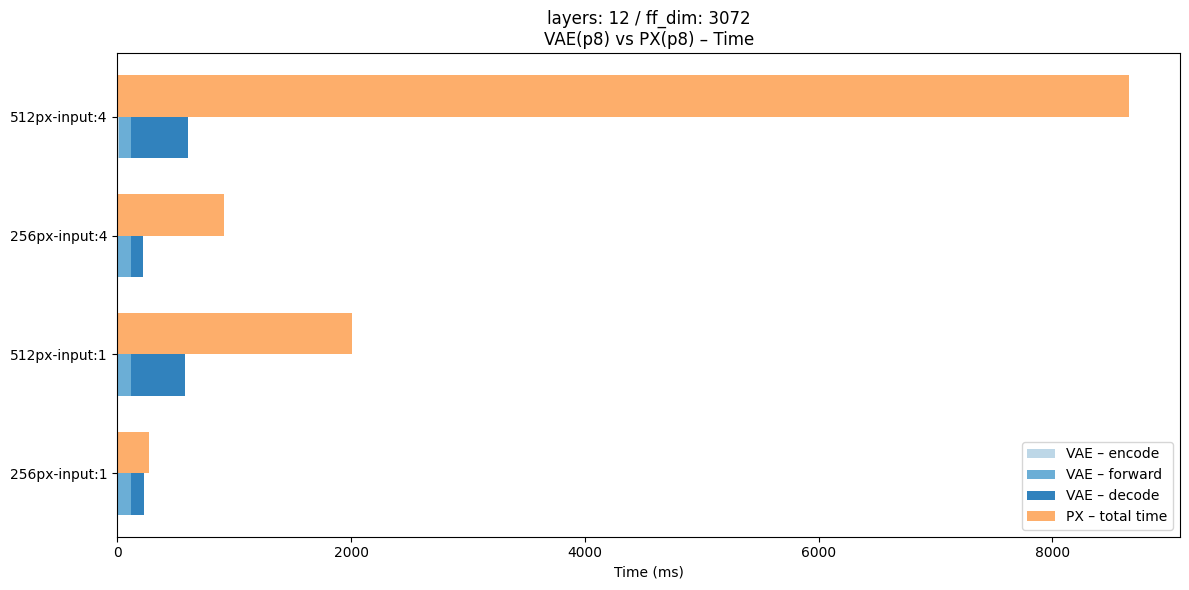

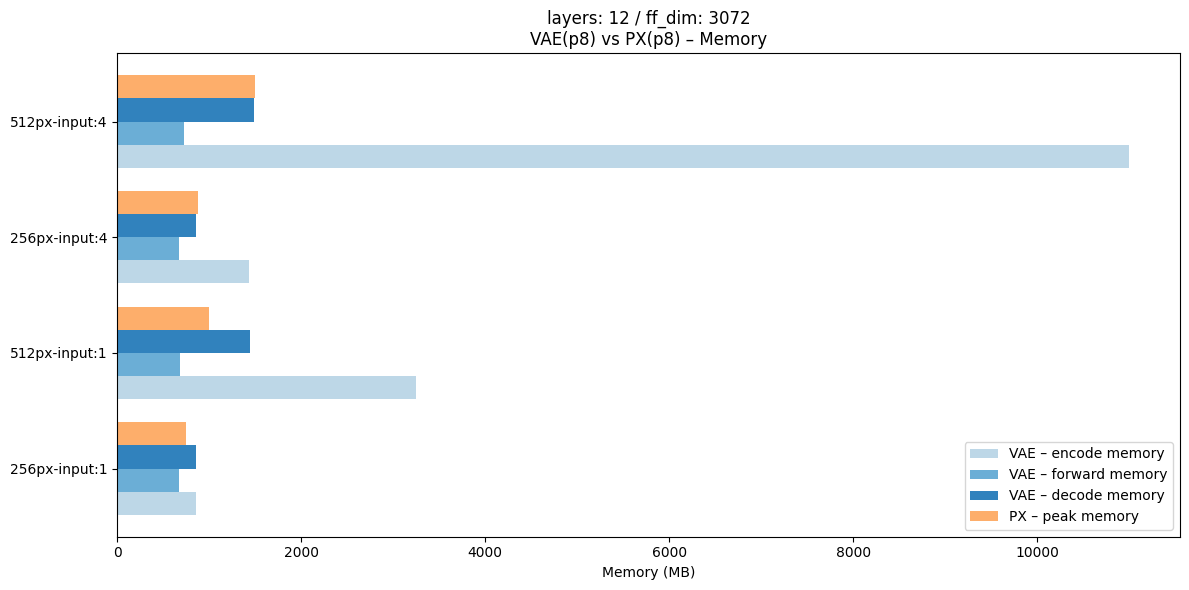

In [ ]:

#############################
# HARD-CODED LEGACY
#############################


import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

path = Path("../results/performance_comparison/260104_results.json")
# path = Path("../results/performance_comparison/results.json")
data = json.loads(path.read_text())

# --- group and average ---
groups = defaultdict(list)
for e in data:
    key = (
        e["model_space"],
        e["patch_size"],
        e["scale_factor"],
        e["ref_views"],
        e["layers"],
        e["dim_feedforward"],
    )
    groups[key].append(e)

mean_results = {}
for key, items in groups.items():
    avg = {}
    for k, v in items[0].items():
        if isinstance(v, (int, float)):
            avg[k] = sum(x[k] for x in items) / len(items)
        else:
            avg[k] = v
    mean_results[key] = avg

print("Total unique configs:", len(mean_results))

# DEBUG: show all keys for layers=6, dim_feedforward=1024
print("\nConfigs with layers=6, dim_feedforward=1024:")
for k in mean_results:
    ms, ps, sf, rv, lyr, dff = k
    if lyr == 6 and dff == 1024:
        print(k)

def collect_subset(patch_vae, patch_px, layers=6, dff=1024):
    """
    Returns (labels, subset), where subset[i] = (vae_dict, px_dict)
    Order corresponds to:
      0: sf=1, rv=1
      1: sf=2, rv=1
      2: sf=1, rv=4
      3: sf=2, rv=4
    """
    labels = ["256px-input:1", "512px-input:1", "256px-input:4", "512px-input:4"]
    conditions = [
        (1, 1),
        (2, 1),
        (1, 4),
        (2, 4),
    ]

    subset = []
    for sf, rv in conditions:
        key_vae = ("VAE", patch_vae, sf, rv, layers, dff)
        key_px  = ("PX",  patch_px,  sf, rv, layers, dff)
        vae = mean_results.get(key_vae)
        px  = mean_results.get(key_px)

        if vae is None or px is None:
            print(f"WARNING: missing config for "
                  f"sf={sf}, rv={rv}, VAE patch={patch_vae}, PX patch={patch_px} "
                  f"(VAE missing? {vae is None}, PX missing? {px is None})")

        subset.append((vae, px))
    return labels, subset



# color scheme: blues for VAE, orange for PX
colors = {
    "vae_encode":  "#bdd7e7",
    "vae_forward": "#6baed6",
    "vae_decode":  "#3182bd",
    "px_total":    "#fdae6b",
}

def plot_subset(labels, subset, title_prefix, layers=6, ff_dim=1024):
    y = np.arange(len(labels))
    h = 0.35

    # If everything is missing, bail early
    if all(v is None and p is None for v, p in subset):
        print(f"No data found for {title_prefix}, skipping plot.")
        return

    # --- TIME ---
    fig, ax = plt.subplots(figsize=(12, 6))

    # replace None with 0 so plotting works, but we still got warnings
    vae_enc = [ (v["encode_time_ms"]  if v else 0) for v, _ in subset ]
    vae_fwd = [ (v["forward_time_ms"] if v else 0) for v, _ in subset ]
    vae_dec = [ (v["decode_time_ms"]  if v else 0) for v, _ in subset ]
    px_total = [ (p["total_time_ms"]  if p else 0) for _, p in subset ]

    ax.barh(y - h/2, vae_enc, h, color=colors["vae_encode"],  label="VAE – encode")
    ax.barh(y - h/2, vae_fwd, h, left=vae_enc, color=colors["vae_forward"], label="VAE – forward")
    ax.barh(y - h/2, vae_dec, h, left=np.array(vae_enc)+np.array(vae_fwd),
            color=colors["vae_decode"], label="VAE – decode")

    ax.barh(y + h/2, px_total, h, color=colors["px_total"], label="PX – total time")

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Time (ms)")
    ax.set_title(f"layers: {layers} / ff_dim: {ff_dim}\n{title_prefix} – Time")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- MEMORY ---
    # fig, ax = plt.subplots(figsize=(12, 6))

    # vae_mem = [ (v["peak_memory_mb"] if v else 0) for v, _ in subset ]
    # px_mem  = [ (p["peak_memory_mb"] if p else 0) for _, p in subset ]

    # ax.barh(y - h/2, vae_mem, h, color=colors["vae_forward"], label="VAE – peak memory")
    # ax.barh(y + h/2, px_mem,  h, color=colors["px_total"],   label="PX – peak memory")

    # ax.set_yticks(y)
    # ax.set_yticklabels(labels)
    # ax.set_xlabel("Peak Memory (MB)")
    # ax.set_title(f"layers: {layers} / ff_dim: {ff_dim}\n{title_prefix} – Memory")
    # ax.legend()
    # plt.tight_layout()
    # plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))

    # extract values
    vae_enc_mem = [ (v["encode_memory_mb"]  if v else 0) for v, _ in subset ]
    vae_fwd_mem = [ (v["forward_memory_mb"] if v else 0) for v, _ in subset ]
    vae_dec_mem = [ (v["decode_memory_mb"]  if v else 0) for v, _ in subset ]
    px_mem      = [ (p["peak_memory_mb"]    if p else 0) for _, p in subset ]

    # vertical spacing so the 3 VAE bars do not overlap
    h = 0.2
    y = np.arange(len(labels))

    # VAE (three separate bars)
    ax.barh(y - 1.5*h, vae_enc_mem, h, color=colors["vae_encode"],  label="VAE – encode memory")
    ax.barh(y - 0.5*h, vae_fwd_mem, h, color=colors["vae_forward"], label="VAE – forward memory")
    ax.barh(y + 0.5*h, vae_dec_mem, h, color=colors["vae_decode"],  label="VAE – decode memory")

    # PX (one bar)
    ax.barh(y + 1.5*h, px_mem, h, color=colors["px_total"], label="PX – peak memory")

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Memory (MB)")
    ax.set_title(f"layers: {layers} / ff_dim: {ff_dim}\n{title_prefix} – Memory")
    ax.legend()
    plt.tight_layout()
    plt.show()

# labels1, subset1 = collect_subset(1, 8)   # VAE(p1) vs PX(p8)
# labels2, subset2 = collect_subset(8, 32)  # VAE(p8) vs PX(32)
# plot_subset(labels1, subset1, "VAE(p1) vs PX(p8)")
# plot_subset(labels2, subset2, "VAE(p8) vs PX(32)")


labels1, subset1 = collect_subset(1, 8, 6, 1024)
plot_subset(labels1, subset1, "VAE(p1) vs PX(p8)", 6, 1024)

labels2, subset2 = collect_subset(8, 64, 6, 1024)
plot_subset(labels2, subset2, "VAE(p8) vs PX(p64)", 6, 1024)

labels3, subset3 = collect_subset(8, 8, 6, 1024)
plot_subset(labels3, subset3, "VAE(p8) vs PX(p8)", 6, 1024)

labels4, subset4 = collect_subset(1, 8, 12, 3072)
plot_subset(labels4, subset4, "VAE(p1) vs PX(p8)", 12, 3072)

labels5, subset5 = collect_subset(8, 64, 12, 3072)
plot_subset(labels5, subset5, "VAE(p8) vs PX(p64)", 12, 3072)

labels6, subset6 = collect_subset(8, 8, 12, 3072)
plot_subset(labels6, subset6, "VAE(p8) vs PX(p8)", 12, 3072)

In [60]:

import gc
import torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
